# 01 — Genre Classification
**Spotify Data Mining | CISC 4631 | Group 3**

**Research Question:** Can audio features predict song genre?

**Approach:** Logistic Regression (linear baseline) vs. Random Forest (non-linear). Compare accuracy,
F1 scores, and feature importance.

> **Prerequisite:** Run `00_data_setup.ipynb` first to generate `data/df_genre_balanced.csv`.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Shared constants (keep in sync with 00_data_setup.ipynb)
SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
MODEL_PATH      = '/content/drive/MyDrive/data-mining-spotify-team3/models'
ALL_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode'
]
np.random.seed(SEED)

## 1. Load Data

In [ ]:
import os
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv'))
print(f'Loaded: {df.shape}')
print('\nGenre counts:')
print(df['genre'].value_counts())
df.head(10)

Loaded: (48265, 14)

Genre counts:
genre
Classical       6895
Country/Folk    6895
Electronic      6895
Hip-Hop/R&B     6895
Jazz/Blues      6895
Pop             6895
Rock            6895
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year
0,0.139,0.0948,-19.576,0.0382,0.9400,0.953000,0.3330,0.0899,142.335,271907,10,1,Classical,2008
1,0.485,0.2280,-11.844,0.0481,0.8810,0.000000,0.1700,0.4020,114.426,137360,2,1,Classical,2002
2,0.439,0.3920,-8.085,0.0305,0.5700,0.000003,0.3340,0.3890,94.393,171280,6,1,Classical,2018
3,0.693,0.5350,-10.377,0.1120,0.3470,0.223000,0.1210,0.4970,159.978,335227,9,1,Classical,2003
4,0.357,0.6990,-5.173,0.0501,0.0508,0.000003,0.4030,0.2290,147.477,251080,7,1,Classical,2018
5,0.411,0.4280,-6.693,0.0596,0.9690,0.000000,0.1460,0.6360,187.605,61160,10,1,Classical,2018
6,0.544,0.7120,-8.031,0.0536,0.2700,0.000079,0.1270,0.6410,87.986,234533,5,1,Classical,2000
7,0.349,0.1010,-20.304,0.0387,0.9430,0.000000,0.0798,0.3060,100.857,220827,3,1,Classical,2004
8,0.299,0.2430,-8.561,0.0364,0.9440,0.000000,0.1120,0.1540,112.248,252440,0,1,Classical,2013
9,0.371,0.2420,-15.371,0.0519,0.2400,0.013200,0.3410,0.1030,170.908,103404,0,1,Classical,2021


## 2. Train / Eval / Test Split

Three-way split (60/20/20) per instructor feedback. Train is used for fitting + 10-fold CV. Eval
is held out for model comparison and tuning decisions. Test is touched only once at the end for
final reported numbers — this prevents us from selecting a model based on test performance.

In [ ]:
X = df[ALL_FEATURES]
y = df['genre']

# First split: 80% train+eval, 20% test (held out, touched once)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Second split: 75/25 of the 80% = 60% train, 20% eval
X_train, X_eval, y_train, y_eval = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f'Train: {X_train.shape[0]:,} ({X_train.shape[0] / len(X):.0%})')
print(f'Eval:  {X_eval.shape[0]:,} ({X_eval.shape[0] / len(X):.0%})')
print(f'Test:  {X_test.shape[0]:,} ({X_test.shape[0] / len(X):.0%})')

print('\nClass distribution (train):')
print(y_train.value_counts())
print('\nClass distribution (eval):')
print(y_eval.value_counts())
print('\nClass distribution (test):')
print(y_test.value_counts())

Train: 28,959 (60%)
Eval:  9,653 (20%)
Test:  9,653 (20%)

Class distribution (train):
genre
Pop             4137
Electronic      4137
Country/Folk    4137
Rock            4137
Hip-Hop/R&B     4137
Classical       4137
Jazz/Blues      4137
Name: count, dtype: int64

Class distribution (eval):
genre
Pop             1379
Electronic      1379
Classical       1379
Rock            1379
Jazz/Blues      1379
Hip-Hop/R&B     1379
Country/Folk    1379
Name: count, dtype: int64

Class distribution (test):
genre
Hip-Hop/R&B     1379
Pop             1379
Country/Folk    1379
Electronic      1379
Rock            1379
Classical       1379
Jazz/Blues      1379
Name: count, dtype: int64


## 3. Feature Selection

Rank the 12 audio features by mutual information with the genre label. Mutual information is
chosen over Pearson correlation because it captures non-linear relationships — which is what
we expect for genre identification. Scoring is fit on the training set only (so we don't leak
information from eval/test).

Mutual information ranking:
         Feature  MI Score
    acousticness  0.245196
          energy  0.188043
    danceability  0.139884
           tempo  0.131408
instrumentalness  0.107156
     speechiness  0.106071
        loudness  0.098925
         valence  0.041976
     duration_ms  0.033367
            mode  0.024316
        liveness  0.015001
             key  0.014307


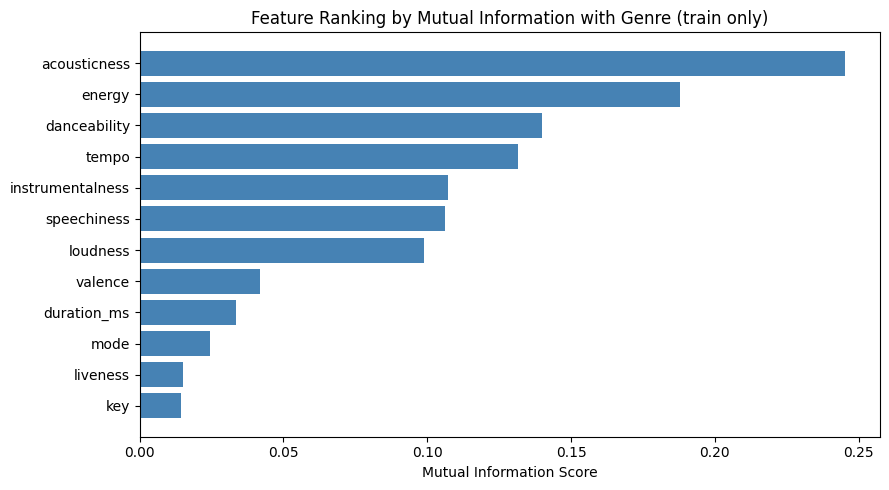


Keeping all 12 features (MI used as ranking diagnostic, not as filter):
['acousticness', 'energy', 'danceability', 'tempo', 'instrumentalness', 'speechiness', 'loudness', 'valence', 'duration_ms', 'mode', 'liveness', 'key']


In [14]:
# Fit mutual-information scorer on train set only
mi_scorer = SelectKBest(score_func=mutual_info_classif, k='all')
mi_scorer.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'MI Score': mi_scorer.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Mutual information ranking:')
print(mi_scores.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_scores['Feature'][::-1], mi_scores['MI Score'][::-1], color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Ranking by Mutual Information with Genre (train only)')
plt.tight_layout()
plt.show()

# Keep all 12 features.
# Tested K=10 (dropping liveness and key) and empirically lost ~1pp
# eval accuracy: tree ensembles extract interaction value from features that look
# near-noise in univariate MI (e.g., XGBoost assigns `mode` ~10% importance despite
# its MI of 0.019). So we use MI as a ranking diagnostic only and keep all features.
K = 12
SELECTED_FEATURES = mi_scores['Feature'].head(K).tolist()
print(f'\nKeeping all {K} features (MI used as ranking diagnostic, not as filter):')
print(SELECTED_FEATURES)

## 4. Models

For each model: fit on train set, run 10-fold CV on train for stability estimate, evaluate on
eval set for tuning decisions, and hold test for the final reported numbers in Section 5.

### 4.1 Logistic Regression (Baseline)

In [15]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED))
])

# Fit on train (selected features only)
lr_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train — estimates stability without touching eval/test
cv_lr = cross_val_score(
    lr_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_lr.mean(), cv_lr.std() * 2))

# Evaluate on eval set
y_pred_lr_eval = lr_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_lr_eval))
print(classification_report(y_eval, y_pred_lr_eval))

# Final test prediction (stored for Section 5 — do not tune against this)
y_pred_lr = lr_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.43 (+/- 0.02)

--- EVAL SET ---
Accuracy: 0.43737698124935254
              precision    recall  f1-score   support

   Classical       0.44      0.49      0.46      1379
Country/Folk       0.28      0.24      0.26      1379
  Electronic       0.51      0.55      0.53      1379
 Hip-Hop/R&B       0.51      0.58      0.54      1379
  Jazz/Blues       0.40      0.39      0.40      1379
         Pop       0.25      0.15      0.19      1379
        Rock       0.53      0.67      0.59      1379

    accuracy                           0.44      9653
   macro avg       0.42      0.44      0.42      9653
weighted avg       0.42      0.44      0.42      9653



### 4.2 Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

# Fit on train (selected features only)
rf_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train
cv_rf = cross_val_score(
    rf_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

# Evaluate on eval set
y_pred_rf_eval = rf_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_rf_eval))
print(classification_report(y_eval, y_pred_rf_eval))

# Final test prediction (stored for Section 5)
y_pred_rf = rf_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.51 (+/- 0.02)

--- EVAL SET ---
Accuracy: 0.5103076763700404
              precision    recall  f1-score   support

   Classical       0.54      0.56      0.55      1379
Country/Folk       0.37      0.34      0.35      1379
  Electronic       0.59      0.61      0.60      1379
 Hip-Hop/R&B       0.56      0.66      0.60      1379
  Jazz/Blues       0.46      0.53      0.49      1379
         Pop       0.34      0.23      0.27      1379
        Rock       0.65      0.65      0.65      1379

    accuracy                           0.51      9653
   macro avg       0.50      0.51      0.50      9653
weighted avg       0.50      0.51      0.50      9653



### 4.3 XGBoost

In [17]:
# XGBoost needs integer-encoded labels — LabelEncoder maps {Classical: 0, ..., Rock: 6}
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_eval_enc  = le.transform(y_eval)
y_test_enc  = le.transform(y_test)

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
)

# Fit on train (selected features only)
xgb_model.fit(X_train[SELECTED_FEATURES], y_train_enc)

# 10-fold CV on train
cv_xgb = cross_val_score(
    xgb_model, X_train[SELECTED_FEATURES], y_train_enc, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_xgb.mean(), cv_xgb.std() * 2))

# Evaluate on eval set (inverse_transform to get back string labels for classification_report)
y_pred_xgb_eval = le.inverse_transform(xgb_model.predict(X_eval[SELECTED_FEATURES]))
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_xgb_eval))
print(classification_report(y_eval, y_pred_xgb_eval))

# Final test prediction (stored for Section 5)
y_pred_xgb = le.inverse_transform(xgb_model.predict(X_test[SELECTED_FEATURES]))

CV Accuracy (train, 10-fold): 0.52 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.5185952553610277
              precision    recall  f1-score   support

   Classical       0.55      0.56      0.55      1379
Country/Folk       0.38      0.37      0.38      1379
  Electronic       0.62      0.63      0.62      1379
 Hip-Hop/R&B       0.58      0.65      0.61      1379
  Jazz/Blues       0.47      0.54      0.50      1379
         Pop       0.32      0.24      0.27      1379
        Rock       0.65      0.65      0.65      1379

    accuracy                           0.52      9653
   macro avg       0.51      0.52      0.51      9653
weighted avg       0.51      0.52      0.51      9653



## 5. Results (Test Set)

Final reported numbers are on the held-out test set

### 5.1 Model Comparison (Test Set)

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  Macro F1  Weighted F1
Logistic Regression  0.435616  0.422283     0.422283
      Random Forest  0.501295  0.493080     0.493080
            XGBoost  0.511862  0.506649     0.506649


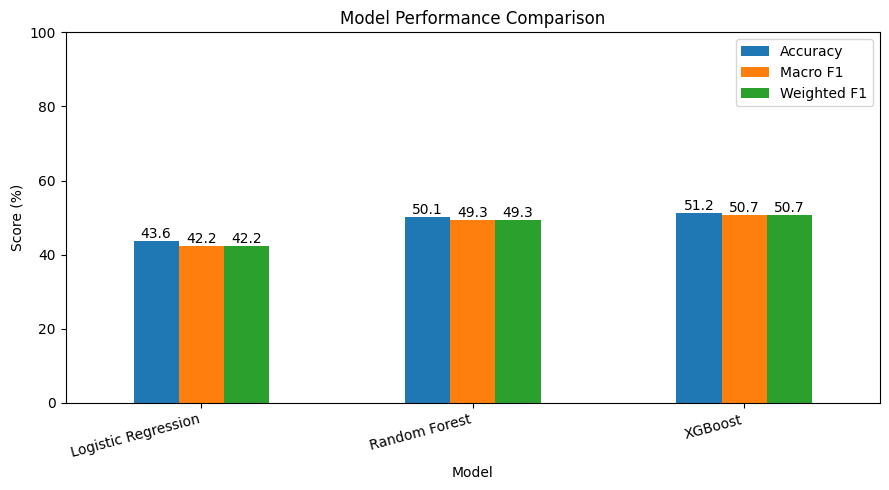

In [19]:
results_pct = results.copy()
results_pct[['Accuracy', 'Macro F1', 'Weighted F1']] *= 100

ax = results_pct.plot(x='Model', y=['Accuracy', 'Macro F1', 'Weighted F1'], kind='bar', figsize=(9, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
plt.tight_layout()
plt.show()

### 5.2 Feature Importance — Random Forest vs XGBoost

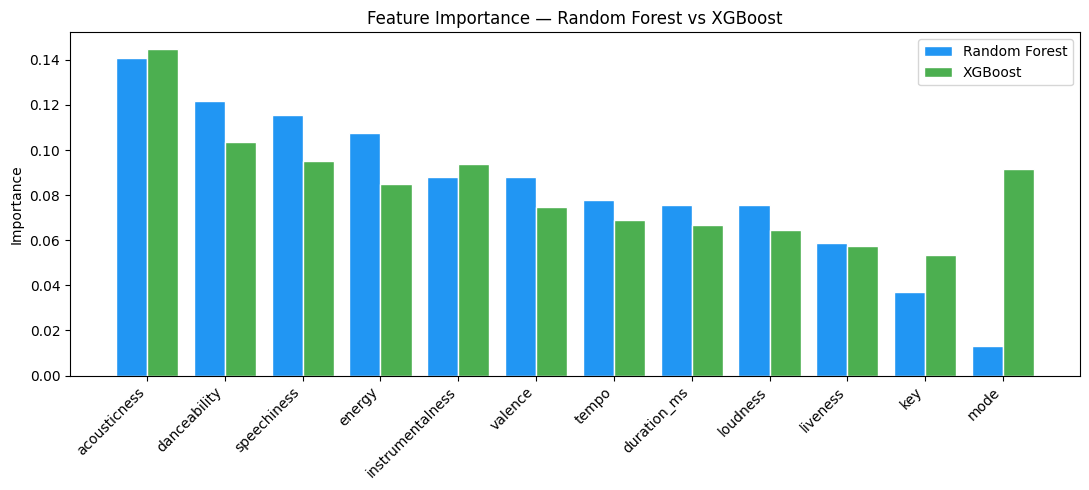

         Feature  Random Forest  XGBoost
    acousticness       0.140804 0.144943
    danceability       0.121745 0.103370
     speechiness       0.115686 0.095344
          energy       0.107659 0.084898
instrumentalness       0.088226 0.093622
         valence       0.087962 0.074897
           tempo       0.077683 0.069183
     duration_ms       0.075727 0.066917
        loudness       0.075403 0.064524
        liveness       0.058863 0.057606
             key       0.036963 0.053280
            mode       0.013280 0.091416


In [20]:
fi_df = pd.DataFrame({
    'Feature': SELECTED_FEATURES,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost':       xgb_model.feature_importances_,
}).sort_values('Random Forest', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(fi_df))
width = 0.4
ax.bar(x - width/2, fi_df['Random Forest'], width, label='Random Forest', color='#2196F3', edgecolor='white')
ax.bar(x + width/2, fi_df['XGBoost'],       width, label='XGBoost',       color='#4CAF50', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(fi_df['Feature'], rotation=45, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Feature Importance — Random Forest vs XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

### 5.3 Confusion Matrix (XGBoost, Test Set)

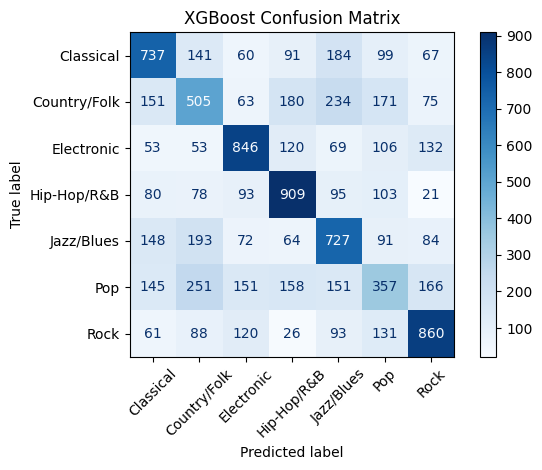

In [21]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=le.classes_,
    cmap='Blues',
    xticks_rotation=45
)
disp.ax_.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Summary

Three classifiers on the same 12 audio features: Logistic Regression (linear baseline), Random Forest (non-linear ensemble), XGBoost (gradient-boosted trees). XGBoost outperforms both RF and LR, supporting the claim that genre boundaries are non-linear and gradient boosting captures subtle feature interactions that bagging and linear fits miss.

**Pipeline summary:**
1. 7 genres after consolidation, each sampled to the minimum-genre count (6,895 per genre, 48,265 total).
2. 60/20/20 train/eval/test split, stratified by genre.
3. Mutual information ranking over the 12 audio features — used as a diagnostic, not a filter. Empirically, dropping low-MI features (`liveness`, `key`) cost ~1pp because tree ensembles extract interaction value that univariate MI misses.
4. Models fit on train; tuned against eval; final numbers reported on test.

**Random-chance baseline for 7-class balanced problem = 14.3%.** All three models significantly exceed this; XGBoost's ~52% represents a ~3.6× lift over random.

**Pickle handoff:** the trained XGBoost model, its `LabelEncoder`, and the `SELECTED_FEATURES` list are saved to Drive so Notebook 03 can load them directly for its retrieve-and-rerank recommender — no retraining.

---
## 7. Save Trained Model

Export XGBoost + metadata to Drive so Nb 03's hybrid recommender can load the classifier directly.

In [22]:
os.makedirs(MODEL_PATH, exist_ok=True)

# Pickle the XGBoost model, its label encoder (for decoding predictions back to genre strings),
# and the selected-feature list (so Nb 03 knows which 10 columns to feed the model at inference).
artifacts = {
    'genre_xgb_model.pkl':     xgb_model,
    'genre_label_encoder.pkl': le,
    'genre_feature_list.pkl':  SELECTED_FEATURES,
}

for fname, obj in artifacts.items():
    with open(os.path.join(MODEL_PATH, fname), 'wb') as f:
        pickle.dump(obj, f)
    print(f'  saved: {os.path.join(MODEL_PATH, fname)}')

  saved: /content/drive/MyDrive/data-mining-spotify-team3/models/genre_xgb_model.pkl
  saved: /content/drive/MyDrive/data-mining-spotify-team3/models/genre_label_encoder.pkl
  saved: /content/drive/MyDrive/data-mining-spotify-team3/models/genre_feature_list.pkl
